In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from matplotlib.colors import LogNorm
import matplotlib
matplotlib.use('TkAgg')
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Helvetica']
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("table_group_params.csv")

In [3]:
rproj_fit_mult=df.rproj_fit_mult.to_numpy()
vproj_fit_mult=df.vproj_fit_mult.to_numpy()
vproj_fit_offset=df.vproj_fit_offset.to_numpy()
gdrproj_fit_mult=df.gd_rproj_fit_mult.to_numpy()
gdvproj_fit_mult=df.gd_vproj_fit_mult.to_numpy()
gdvproj_fit_offset=df.gd_vproj_fit_offset.to_numpy()
labels=["({a:d},{b:d},{c:d},{d:d},{e:d},{f:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii], d=gdrproj_fit_mult[ii], e=gdvproj_fit_mult[ii], f=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
labels_for_giant_params=["({a:d}, {b:d}, {c:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'labels_giant_params']=labels_for_giant_params

In [4]:
giantresults = df.groupby('labels_giant_params').median()
giantresults=giantresults[(giantresults.rproj_fit_mult>1)&(giantresults.vproj_fit_mult>1)]

In [5]:
giantresults

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(2, 2, 100)",2.0,2.0,100.0,3.5,3.5,150.0,0.163,0.226746,0.2215,0.992472,...,0.886920,0.989844,0.948337,0.962562,0.945694,0.921560,0.953707,0.1720,7864.0,328.0
"(2, 2, 200)",2.0,2.0,200.0,3.5,3.5,150.0,0.162,0.246633,0.2175,0.992058,...,0.893478,0.990130,0.950831,0.963146,0.950705,0.922300,0.957619,0.1715,7754.0,324.0
"(2, 2, 300)",2.0,2.0,300.0,3.5,3.5,150.0,0.161,0.266875,0.2170,0.991658,...,0.897388,0.990229,0.951532,0.962712,0.952514,0.922211,0.958062,0.1740,7698.0,320.0
"(2, 3, 100)",2.0,3.0,100.0,3.5,3.5,150.0,0.162,0.263455,0.2200,0.992225,...,0.893273,0.990296,0.949831,0.962561,0.951539,0.921186,0.956982,0.1720,7769.0,327.0
"(2, 3, 200)",2.0,3.0,200.0,3.5,3.5,150.0,0.161,0.268030,0.2130,0.991878,...,0.898353,0.990369,0.951497,0.963631,0.953533,0.921870,0.958491,0.1740,7696.0,323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",6.0,5.0,200.0,3.5,3.5,150.0,0.203,0.854550,0.5200,0.964970,...,0.971664,0.977973,0.985338,0.914003,0.986575,0.754550,0.988072,0.2730,5675.5,408.0
"(6, 5, 300)",6.0,5.0,300.0,3.5,3.5,150.0,0.205,0.869930,0.5195,0.963597,...,0.972825,0.976935,0.986175,0.912836,0.986789,0.759259,0.989194,0.2770,5623.5,411.0
"(6, 6, 100)",6.0,6.0,100.0,3.5,3.5,150.0,0.202,0.853649,0.5150,0.966588,...,0.969526,0.978437,0.984136,0.910142,0.984177,0.751938,0.986442,0.2720,5703.5,407.0


In [6]:
giantmaxs=df.groupby('labels_giant_params').max()
giantmins = df.groupby('labels_giant_params').min()

In [7]:
giantrangedf = giantmaxs-giantmins

In [8]:
giantrangedf

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(1, 1, 100)",0,0,0,5,5,300,0.006,0.000000,0.0,0.002982,...,0.043102,0.006507,0.024159,0.057088,0.072034,0.103477,0.053444,0.02200,494,468
"(1, 1, 200)",0,0,0,5,5,300,0.005,0.000000,0.0,0.002779,...,0.042118,0.006014,0.023773,0.053746,0.057565,0.097983,0.045454,0.02300,472,450
"(1, 1, 300)",0,0,0,5,5,300,0.005,0.000000,0.0,0.002662,...,0.040569,0.005692,0.023100,0.051651,0.049279,0.092309,0.040234,0.02050,452,432
"(1, 2, 100)",0,0,0,5,5,300,0.005,0.000000,0.0,0.002901,...,0.042467,0.006390,0.023961,0.055810,0.060477,0.099988,0.048656,0.02150,480,456
"(1, 2, 200)",0,0,0,5,5,300,0.005,0.000000,0.0,0.002819,...,0.042298,0.006215,0.024069,0.054539,0.052563,0.098525,0.044701,0.02300,472,449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",0,0,0,5,5,300,0.015,0.000000,0.0,0.012556,...,0.050108,0.029235,0.026035,0.117324,0.029117,0.137420,0.022927,0.03975,478,428
"(6, 5, 300)",0,0,0,5,5,300,0.016,0.004004,0.0,0.013505,...,0.049627,0.031339,0.025665,0.122932,0.025825,0.128732,0.021687,0.03925,486,430
"(6, 6, 100)",0,0,0,5,5,300,0.014,0.000000,0.0,0.012725,...,0.051317,0.029060,0.026853,0.116217,0.030651,0.156468,0.023761,0.03950,491,440


# Lollipop chart for selecting dwarf-association parameters

In [9]:
pg=giantresults.P_G.to_numpy()
cg=giantresults.C_G.to_numpy()
ph=giantresults.P_H.to_numpy()
ch=giantresults.C_H.to_numpy()
mu_phys=giantresults.mu_HME.to_numpy()
mu=giantresults.mu_HME.to_numpy()#/np.median(giantresults.mu_HME.to_numpy())
fn=interp1d([np.max(mu),np.min(mu)],[0.7,1])
mu=fn(mu)
mu_dyn=giantresults.mu_HME_dyn.to_numpy()
mu_dyn_rank = interp1d([np.max(mu_dyn),np.min(mu_dyn)],[0.7,1])(mu_dyn)
#mu=1-rankdata(mu,'max')/len(x)
pgtimescg=pg*cg
phtimesch=ph*ch
pgrange=giantrangedf.P_G.to_numpy()
cgrange=giantrangedf.C_G.to_numpy()
phrange=giantrangedf.P_H.to_numpy()
chrange=giantrangedf.C_H.to_numpy()
mu_physrange=giantrangedf.mu_HME.to_numpy()

order=np.argsort(pgtimescg)
pg=pg[order]
cg=cg[order]
ch=ch[order]
ph=ph[order]
mu=mu[order]
mu_dyn=mu_dyn[order]
mu_dyn_rank=mu_dyn_rank[order]
mu_phys=mu_phys[order]
phtimesch=phtimesch[order]
pgtimescg=pgtimescg[order]
pgrange=pgrange[order]
cgrange=cgrange[order]
phrange=phrange[order]
chrange=chrange[order]
newlabels=np.array(giantresults.index.to_numpy())[order]

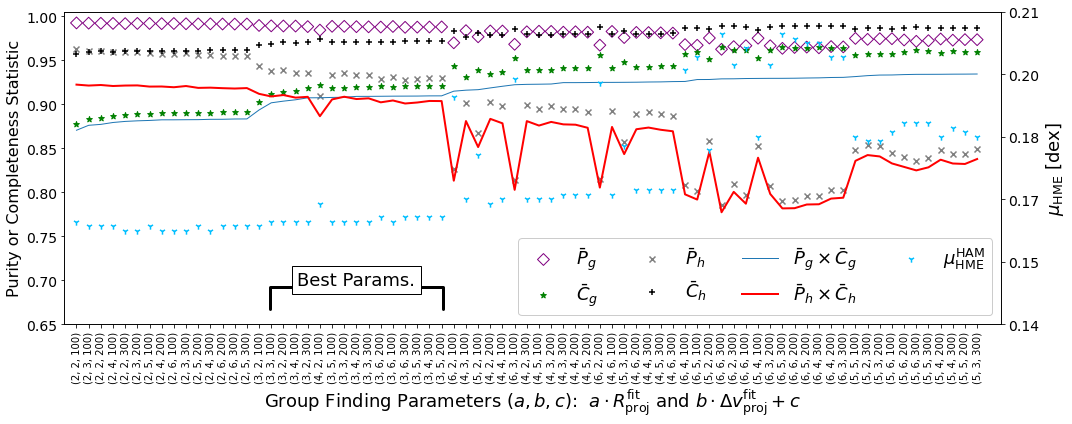

In [10]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,6))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label=r'$\bar{P}_{g}$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label=r'$\bar{C}_{g}$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label=r'$\bar{P}_{h}$')
ax.scatter(myrange-1,ch,color='k',marker='+', label=r'$\bar{C}_{h}$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=1,label=r'$\bar{P}_g \times \bar{C}_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$\bar{P}_h \times \bar{C}_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=10)
ax.set_ylim(0.65,1.005)
ytvals = np.arange(0.65,1.05,0.05)
ax.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=16)
ax1=ax.twinx()
ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)

hme_ylim = [0.14,0.21]
step=(hme_ylim[1]-hme_ylim[0])/5.
ax1.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
ax1.set_yticks(hme_ytvals, ["{:0.2f}".format(x) for x in hme_ytvals], fontsize=14)

ax.legend(loc='lower right', framealpha=1, fontsize=18, ncol=4)
ax.annotate(r'Best Params.', xy=(23,0.69), 
            fontsize=18, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white'),
            arrowprops=dict(arrowstyle='-[, widthB=4.8, lengthB=1.2', lw=3.0))
#ax.annotate(r"Parameters $(a,b,c)$:  $a\cdot R_{\rm proj}^{\rm fit}$ and $b \cdot \Delta v_{\rm proj}^{\rm fit}+c$",\
#            xy=(1,0.67),fontsize=18)
ax.set_xlabel(r"Group Finding Parameters $(a,b,c)$:  $a\cdot R_{\rm proj}^{\rm fit}$ and $b \cdot \Delta v_{\rm proj}^{\rm fit}+c$",\
              fontsize=18)
plt.tight_layout()
plt.savefig("../figures/optimal_params_giants.pdf",dpi=300)
plt.show()

Dynamical masses?

In [11]:
diff = np.abs(df.mu_HME_dyn - df.mu_HME_HAMngt7)
df.loc[:,'diff']=diff

In [12]:
df.sort_values(by='diff')

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params,diff
216,1,1,200,4,1,0,0.169,0.220417,0.218,0.994098,...,0.931120,0.964286,0.896639,0.930688,0.914012,0.1755,8483,224,"(1, 1, 200)",0.002417
569,1,2,100,6,5,100,0.166,0.220417,0.218,0.992107,...,0.945008,0.946405,0.908643,0.898823,0.928970,0.1570,8196,510,"(1, 2, 100)",0.002417
570,1,2,100,6,5,200,0.166,0.220417,0.218,0.992107,...,0.945008,0.946405,0.908643,0.898823,0.928970,0.1570,8196,510,"(1, 2, 100)",0.002417
571,1,2,100,6,5,300,0.166,0.220417,0.218,0.992107,...,0.945008,0.946405,0.908643,0.898823,0.928970,0.1570,8196,510,"(1, 2, 100)",0.002417
572,1,2,100,6,6,0,0.166,0.220417,0.218,0.992107,...,0.945008,0.946405,0.908643,0.898823,0.928970,0.1575,8196,510,"(1, 2, 100)",0.002417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15526,6,6,300,5,6,200,0.209,0.931467,0.521,0.956906,...,0.989097,0.865954,0.986020,0.724944,0.989091,0.2890,5455,522,"(6, 6, 300)",0.410467
15501,6,6,300,4,6,100,0.208,0.931467,0.521,0.959904,...,0.988699,0.896984,0.987945,0.761005,0.988951,0.2800,5503,477,"(6, 6, 300)",0.410467
15424,6,6,300,1,5,0,0.197,0.931467,0.521,0.966632,...,0.970321,0.946048,0.979968,0.759124,0.984793,0.2690,5807,208,"(6, 6, 300)",0.410467
15519,6,6,300,5,4,300,0.209,0.931467,0.521,0.956908,...,0.989157,0.865954,0.986020,0.724944,0.989091,0.2890,5455,522,"(6, 6, 300)",0.410467


In [13]:
df[df.labels_giant_params=='(3, 4, 200)']

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params,diff
6624,3,4,200,1,1,0,0.162,0.400711,0.225,0.989588,...,0.945773,0.937678,0.938034,0.812500,0.949653,0.2390,7389,78,"(3, 4, 200)",0.175711
6625,3,4,200,1,1,100,0.162,0.400711,0.225,0.989530,...,0.949593,0.962607,0.961538,0.878378,0.966216,0.2115,7336,130,"(3, 4, 200)",0.175711
6626,3,4,200,1,1,200,0.162,0.400711,0.225,0.989530,...,0.949593,0.962607,0.961538,0.878378,0.966216,0.2115,7336,130,"(3, 4, 200)",0.175711
6627,3,4,200,1,1,300,0.162,0.400711,0.225,0.989530,...,0.949593,0.962607,0.961538,0.878378,0.966216,0.2115,7336,130,"(3, 4, 200)",0.175711
6628,3,4,200,1,2,0,0.161,0.400711,0.225,0.989544,...,0.948641,0.958452,0.957265,0.866667,0.962963,0.1910,7349,117,"(3, 4, 200)",0.175711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6763,3,4,200,6,5,300,0.163,0.400711,0.225,0.985226,...,0.972248,0.922090,0.972552,0.851865,0.974121,0.1965,6933,505,"(3, 4, 200)",0.175711
6764,3,4,200,6,6,0,0.164,0.400711,0.225,0.985202,...,0.972245,0.921605,0.972498,0.850187,0.974121,0.1955,6931,504,"(3, 4, 200)",0.175711
6765,3,4,200,6,6,100,0.164,0.400711,0.225,0.985202,...,0.972245,0.921605,0.972498,0.850187,0.974121,0.1955,6931,504,"(3, 4, 200)",0.175711
6766,3,4,200,6,6,200,0.164,0.400711,0.225,0.985222,...,0.972245,0.921936,0.972498,0.851616,0.974078,0.1955,6932,504,"(3, 4, 200)",0.175711


In [15]:
min(df.mu_HME_dyn)

0.2204167791946574

In [ ]:
len(ph)

In [ ]:
# myrange=np.arange(1,len(pg)+1)
# fig,ax=plt.subplots(figsize=(15,4))
# ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
# ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
# ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
# ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
# ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
# ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
# ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
# ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
# ax.set_ylim(0.7,1.0)
# ax.set_xlim(-1,max(myrange)+1)
# ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
# ax1=ax.twinx()
# #ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
# ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
# #ax1.set_ylim(0.15,0.18)

# ax.legend(loc='lower left', framealpha=1, fontsize=12, ncol=4)
# plt.show()

In [ ]:
# myrange=np.arange(1,len(pg)+1)
# fig,ax=plt.subplots(figsize=(15,4))
# ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
# ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
# ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
# ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
# ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
# ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
# ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
# ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
# ax.set_ylim(0.7,1.0)
# ax.set_xlim(-1,max(myrange)+1)
# ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
# #ax1=ax.twinx()
# ax.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax.scatter(myrange-1,mu_dyn_rank,marker='2',color='olive',s=60, label=r'$\mu_{\rm HME}^{\rm dyn}$')
# #ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# #ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
# ax.set_ylim(0.68,1.02)
# ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
# plt.show()